# Data Preprocessing Pipeline

In [12]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import scipy.sparse as sp
from anndata import AnnData
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from muon import atac as ac  

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed" / "mESC_preprocessing_testing" / "E7.5_rep1"

if not os.path.isdir(PROCESSED_DATA_DIR):
    os.makedirs(PROCESSED_DATA_DIR)

logging.basicConfig(level=logging.INFO, format="%(message)s")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Settings

In [13]:
# Minimum number of genes and peaks required for a cell to be retained
MIN_GENES_PER_CELL = 1000
MIN_PEAKS_PER_CELL = 1000

# Percentage of lowest expressed genes and least accessible peaks to filter out
FILTER_OUT_LOWEST_PCT_GENES = 0.10
FILTER_OUT_LOWEST_PCT_PEAKS = 0.10

# Maximum percentage of mitochondrial gene expression allowed for a cell to be retained
MAX_PCT_MT = 20

# Minimum dispersion threshold for selecting highly variable features
MIN_RNA_DISP = 0.5
MIN_ATAC_DISP = 0.5

# Parameters for dimensionality reduction and clustering
PCA_COMPONENTS = 20
NEIGHBORS_K = 20
HOPS = 2

## Load the data into AnnData objects

Load the reference file with TF names

In [14]:
organism_code = "mm10"
tf_file = PROJECT_DIR / "data" / "databases" / "motif_information" / organism_code / "TF_Information_all_motifs.txt"
tf_ref = pd.read_csv(tf_file, sep=None, engine="python")["TF_Name"].unique()
print(f"First 5 TFs for mESC:")
print(tf_ref[:5])

First 5 TFs for mESC:
['Tfap2a' 'Tfap2b' 'Tfap2c' 'Tfap2e' 'Tfap2d']


Load in the raw data

In [15]:
DATA_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/")

sample_name = "E7.5_rep1"
raw_rna_file = DATA_DIR / "raw" / "mESC" / sample_name / "scRNA_seq_raw.parquet"
raw_atac_file = DATA_DIR / "raw" / "mESC" / sample_name / "scATAC_seq_raw.parquet"

raw_rna_df = pd.read_parquet(raw_rna_file, engine="pyarrow")
raw_atac_df = pd.read_parquet(raw_atac_file, engine="pyarrow")

print(f"Raw RNA-seq data shape: {raw_rna_df.shape}")
print(f"Raw ATAC-seq data shape: {raw_atac_df.shape}")

Raw RNA-seq data shape: (8936, 32285)
Raw ATAC-seq data shape: (7416, 192248)


Convert the DataFrames into AnnData objects and ensure that the barcodes match

In [16]:
ad_rna = AnnData(raw_rna_df)
ad_atac = AnnData(raw_atac_df)

def normalize_barcodes(index_like: pd.Index) -> pd.Index:
    """Normalizes cell barcodes by stripping common suffixes and standardizing case."""
    ix = pd.Index(index_like).astype(str)
    ix = ix.str.replace(r"_\d+$", "", regex=True)
    ix = ix.str.replace(r"[-\.]\d+$", "", regex=True)
    ix = ix.str.replace(r"(?:_RNA|_GEX|_ATAC|#GEX|#ATAC)$", "", regex=True, case=False)
    return ix.str.upper()

# Normalize the barcodes and get their indices
rna_norm = normalize_barcodes(ad_rna.obs_names)
atac_norm = normalize_barcodes(ad_atac.obs_names)

# Make a map of the intersecting cell names
r_map = pd.Series(ad_rna.obs_names, index=rna_norm, dtype="object")
a_map = pd.Series(ad_atac.obs_names, index=atac_norm, dtype="object")
common = r_map.index.intersection(a_map.index)

# Subset the AnnData objects to the common cells and set the obs_names to the common cell names
ad_rna = ad_rna[r_map.loc[common].values, :]
ad_atac = ad_atac[a_map.loc[common].values, :]
ad_rna.obs_names = common
ad_atac.obs_names = common

Create a `"log1p"` layer to store normalized counts

In [5]:
ad_rna.layers["counts"] = ad_rna.X.copy()
ad_atac.layers["counts"] = ad_atac.X.copy()

In [6]:
rna_barcodes = ad_rna.obs_names
atac_barcodes = ad_atac.obs_names

gene_names = ad_rna.var_names
peak_names = ad_atac.var_names

print(f"Number of cells in RNA-seq data: {ad_rna.n_obs:,}")
print(f"Number of cells in ATAC-seq data: {ad_atac.n_obs:,}")
print(f"\nNumber of genes in RNA-seq data: {ad_rna.n_vars:,}")
print(f"Number of peaks in ATAC-seq data: {ad_atac.n_vars:,}")

Number of cells in RNA-seq data: 7,416
Number of cells in ATAC-seq data: 7,416

Number of genes in RNA-seq data: 32,285
Number of peaks in ATAC-seq data: 192,248


## Filtering and QC

Store the cell barcodes so that we can subset to only cells that pass both the RNA and ATAC QC filtering.

In [7]:
ad_rna.obs['barcode'] = ad_rna.obs_names
ad_atac.obs['barcode'] = ad_atac.obs_names

### Filter Mitochondrial Genes

Label mitochondrial genes that could be in the dataset. Filter out cells where the percent mitochondrial genes is >5%

13 mitochondrial genes identified in RNA-seq data.
101 ribosomal genes identified in RNA-seq data.
12 hemoglobin genes identified in RNA-seq data.


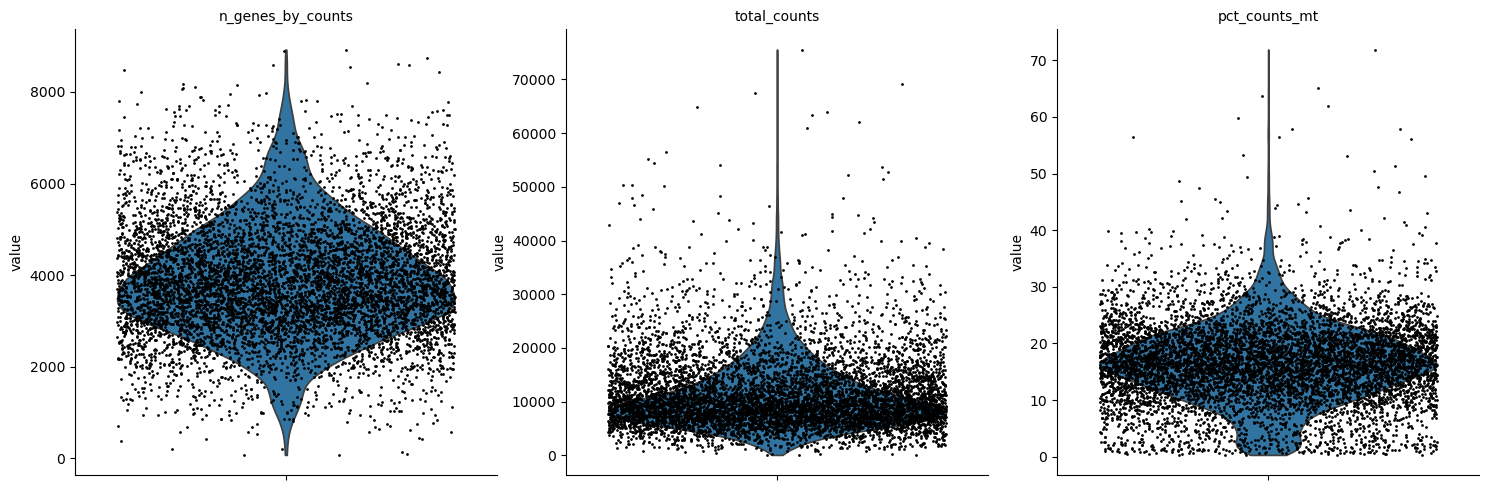

In [8]:
# Label mitochondrial genes
ad_rna.var['mt'] = ad_rna.var_names.str.lower().str.startswith("mt-")
print(f"{ad_rna.var['mt'].sum()} mitochondrial genes identified in RNA-seq data.")

# Label ribosomal genes
ad_rna.var["ribo"] = ad_rna.var_names.str.lower().str.startswith(("rps", "rpl"))
print(f"{ad_rna.var['ribo'].sum()} ribosomal genes identified in RNA-seq data.")

# Label hemoglobin genes
ad_rna.var["hb"] = ad_rna.var_names.str.lower().str.contains("^hb[^(p)]")
print(f"{ad_rna.var['hb'].sum()} hemoglobin genes identified in RNA-seq data.")

sc.pp.calculate_qc_metrics(ad_rna, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
sc.pl.violin(
    ad_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    size=2,
)


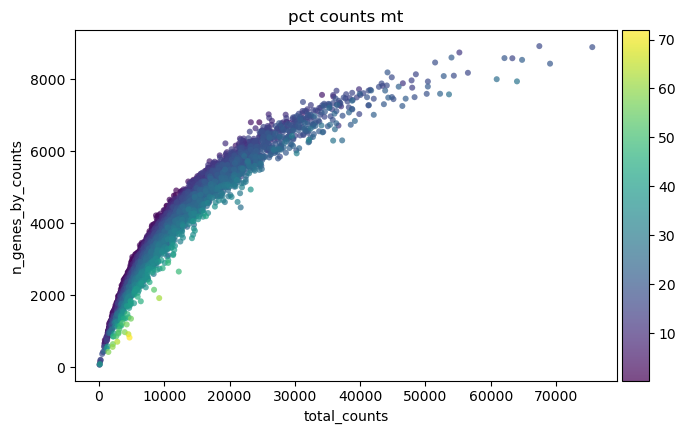

In [9]:
sc.pl.scatter(ad_rna, "total_counts", "n_genes_by_counts", color="pct_counts_mt", size=75, alpha=0.7)

In [ ]:
ad_rna = ad_rna[ad_rna.obs.pct_counts_mt < MAX_PCT_MT]

Make gene names unique and store them in a separate `"gene_ids"` layer.

In [11]:
ad_rna.var_names_make_unique()
ad_rna.var['gene_ids'] = ad_rna.var.index

### Filter cells with low read count

Filter out cells with fewer than `MIN_GENES_PER_CELL` genes and with fewer than `MIN_PEAKS_PER_CELL` peaks

In [ ]:
print(f"Cells before filtering: RNA-seq = {ad_rna.n_obs:,}, ATAC-seq = {ad_atac.n_obs:,}")

sc.pp.filter_cells(ad_rna, min_genes=MIN_GENES_PER_CELL)
sc.pp.filter_cells(ad_atac, min_genes=MIN_PEAKS_PER_CELL)

print(f"Cells after filtering: RNA-seq = {ad_rna.n_obs:,}, ATAC-seq = {ad_atac.n_obs:,}")

Determine which genes are TFs in the dataset

In [ ]:
ad_rna.var["tf_ids"] = ad_rna.var_names.isin(tf_ref)
print(f"TFs in the dataset: {ad_rna.var['tf_ids'].sum()}")

### Filter out genes and peaks expressed in few cells

Filters out genes which are expressed in fewer than `FILTER_OUT_LOWEST_PCT_GENES` cells and peaks which are accessible in fewer than `FILTER_OUT_LOWEST_PCT_PEAKS` cells.

In [ ]:
min_num_cells_rna = ad_rna.n_obs * FILTER_OUT_LOWEST_PCT_GENES
min_num_cells_atac = ad_atac.n_obs * FILTER_OUT_LOWEST_PCT_PEAKS

print(f"Filtering out genes expressed in fewer than {FILTER_OUT_LOWEST_PCT_GENES*100:.1f}% of cells. (Minimum cells: {min_num_cells_rna:.0f})")
print(f"  - Genes before filtering: {ad_rna.n_vars:,} ({ad_rna.var['tf_ids'].sum()} TFs)")
sc.pp.filter_genes(ad_rna, min_cells=min_num_cells_rna)
print(f"  - Genes after filtering: {ad_rna.n_vars:,} ({ad_rna.var['tf_ids'].sum()} TFs)")

print(f"\nFiltering out peaks expressed in fewer than {FILTER_OUT_LOWEST_PCT_PEAKS*100:.1f}% of cells. (Minimum cells: {min_num_cells_atac:.0f})")
print(f"  - Peaks before filtering: {ad_atac.n_vars:,} ")
sc.pp.filter_genes(ad_atac, min_cells=min_num_cells_atac)
print(f"  - Peaks after filtering: {ad_atac.n_vars:,}")


### Doublet Detection

In [ ]:
sc.pp.scrublet(ad_rna)

# Filter out doublets
ad_rna = ad_rna[~ad_rna.obs["predicted_doublet"], :]

### Normalization

In [ ]:
sc.pp.normalize_total(ad_rna, target_sum=1e4)
sc.pp.normalize_total(ad_atac, target_sum=1e4)

sc.pp.log1p(ad_rna)
sc.pp.log1p(ad_atac)

### Feature Selection

In [ ]:


sc.pp.highly_variable_genes(ad_rna, min_mean=0.0125, max_mean=3, min_disp=MIN_RNA_DISP)
sc.pp.highly_variable_genes(ad_atac, min_mean=0.0125, max_mean=3, min_disp=MIN_ATAC_DISP)

n_hvg_genes = ad_rna.var.highly_variable.sum()
n_hvg_peaks = ad_atac.var.highly_variable.sum()

print(f"Num Highly Variable Features: {n_hvg_genes} Genes, {n_hvg_peaks} Peaks")

sc.pl.highly_variable_genes(ad_rna)
sc.pl.highly_variable_genes(ad_atac)

Store the normalized expression and accessibility to a `"log1p"` layer.

In [ ]:
ad_rna.layers["log1p"] = ad_rna.X
ad_atac.layers["log1p"] = ad_atac.X

### Dimensionality Reduction

In [ ]:
sc.tl.pca(ad_rna, n_comps=PCA_COMPONENTS, svd_solver="arpack")
sc.pl.pca_variance_ratio(ad_rna, n_pcs=PCA_COMPONENTS, log=True)

sc.tl.pca(ad_atac, n_comps=PCA_COMPONENTS, svd_solver="arpack")
sc.pl.pca_variance_ratio(ad_atac, n_pcs=PCA_COMPONENTS, log=True)

Plotting to see if there are any undesireable features in the RNA-seq dataset driving significant variation.

In [ ]:
sc.pl.pca(
    ad_rna,
    color=["pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=10,
)

Get the common cells after filtering

In [ ]:
common = ad_rna.obs_names.intersection(ad_rna.obs_names)
ad_rna = ad_rna[common].copy()
ad_atac = ad_atac[common].copy()

print(f"Number of cells after filtering: {ad_rna.n_obs} in RNA, {ad_atac.n_obs} in ATAC")

Save the processed data files

In [121]:
def _adata_to_feature_by_cell_df(adata: AnnData) -> pd.DataFrame:
    if "log1p" in adata.layers:
        X = adata.layers["log1p"]
    elif "counts" in adata.layers:
        X = adata.layers["counts"]
    else:
        X = adata.X
    if sp.issparse(X):
        arr = X.T.toarray()
    else:
        arr = np.asarray(X, dtype=np.float32).T
    return pd.DataFrame(arr, index=adata.var_names.astype(str), columns=adata.obs_names.astype(str))

def standardize_name(name: str) -> str:
    """Convert gene/motif name to upper style (e.g. 'HOXA2')."""
    if not isinstance(name, str):
        return name
    return name.upper()

processed_rna_file = PROCESSED_DATA_DIR / "scRNA_seq_processed.parquet"
processed_atac_file = PROCESSED_DATA_DIR / "scATAC_seq_processed.parquet"

adata_rna_file = PROCESSED_DATA_DIR / "adata_RNA.h5ad"
adata_atac_file = PROCESSED_DATA_DIR / "adata_ATAC.h5ad"

processed_rna_df = _adata_to_feature_by_cell_df(ad_rna).astype("float32")
processed_rna_df.index = processed_rna_df.index.astype(str).map(standardize_name)

processed_atac_df = _adata_to_feature_by_cell_df(ad_atac).astype("float32")

processed_rna_df.to_parquet(processed_rna_file, engine="pyarrow", compression="snappy")
processed_atac_df.to_parquet(processed_atac_file, engine="pyarrow", compression="snappy")

ad_rna.write_h5ad(adata_rna_file)
ad_atac.write_h5ad(adata_atac_file)


## Nearest Neighbor Graph Construction and Visualization

Create a joint embedding of both the RNA and ATAC data

In [ ]:
combined_pca = np.concatenate((ad_rna.obsm["X_pca"], ad_atac.obsm["X_pca"]), axis=1)
joint = AnnData(X=sp.csr_matrix((ad_rna.n_obs, 0)), obs=ad_rna.obs.copy())
joint.obsm["X_combined"] = combined_pca

In [ ]:
sc.pp.neighbors(joint, n_neighbors=NEIGHBORS_K, use_rep="X_combined")

Visualize the embeddings with UMAP

In [ ]:
sc.tl.umap(joint)
sc.pl.umap(
    joint,
    size=25,
)

### Clustering

In [ ]:
sc.tl.leiden(joint, flavor="igraph", n_iterations=2)
sc.pl.umap(joint, color=["leiden"])

In [ ]:
sc.pl.umap(
    joint,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.2
)

In [ ]:
sc.pl.umap(
    joint,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.1,
    ncols=2,
)

## Metacell Generation

In [95]:
def plot_W_subset(W, n_cells=200, title=""):
    if sp.issparse(W):
        W_sub = W[:n_cells, :n_cells].toarray()
    else:
        W_sub = np.asarray(W[:n_cells, :n_cells])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        W_sub,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.5}
    )
    plt.title(title)
    plt.xlabel("Neighbor Cells")
    plt.ylabel("Cells")
    plt.tight_layout()
    plt.show()

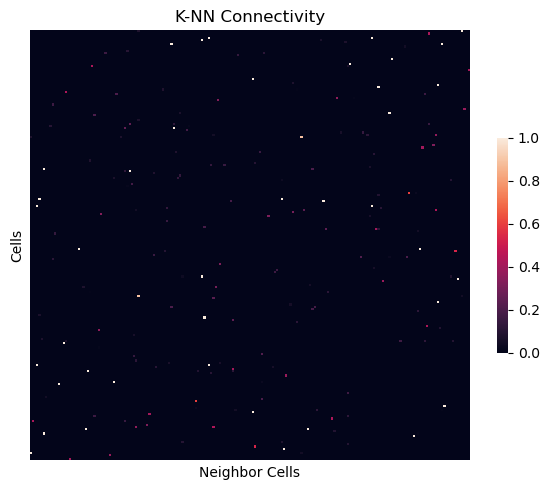

In [104]:
# Base connectivities between cells from the K-NN graph
W = joint.obsp["connectivities"].tocsr().astype(np.float32)

plot_W_subset(W, title="K-NN Connectivity")

Add the cell identity to the connections

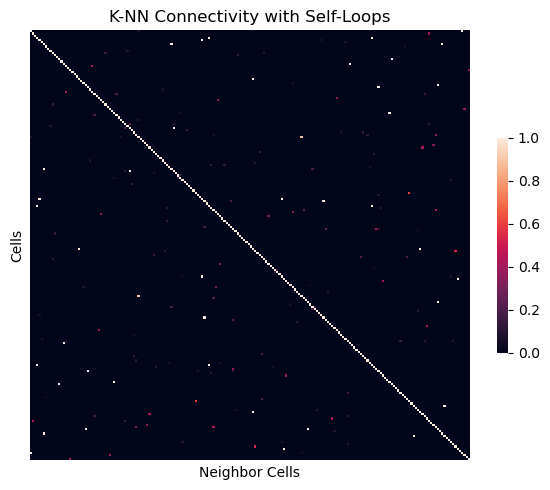

In [105]:
W = W + sp.diags(np.full(W.shape[0], 1, dtype=np.float32), format="csr")

plot_W_subset(W, title="K-NN Connectivity with Self-Loops")

Row normalize

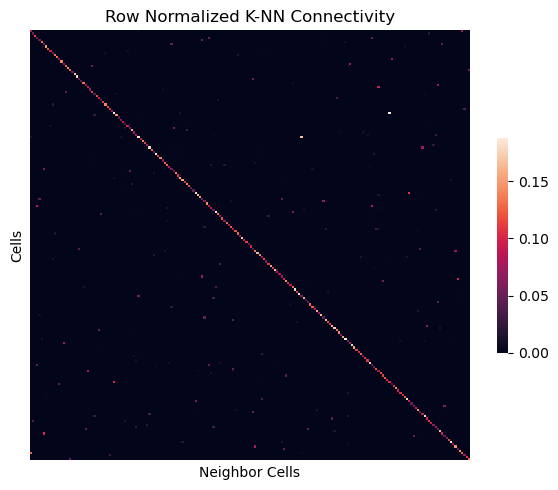

In [106]:
def row_norm(mat: sp.csr_matrix) -> sp.csr_matrix:
    row_sum = np.asarray(mat.sum(axis=1)).ravel()
    row_sum[row_sum == 0] = 1.0
    inv = sp.diags(1.0 / row_sum, dtype=np.float32)
    return inv @ mat

W = row_norm(W)

plot_W_subset(W, title="Row Normalized K-NN Connectivity")

Multi-hop diffusion to determine how much each cell's neighbors should be blended with its own expression.

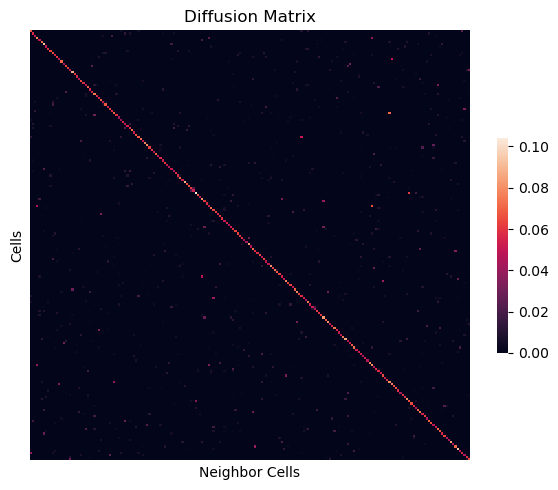

In [ ]:
W_h = W
for _ in range(1, int(HOPS)):
    W_h = W_h @ W 
    W_h = row_norm(W_h)
W = W_h

# Final row normalization to make sure rows sum to 1
W = row_norm(W)

plot_W_subset(W, title="Diffusion Matrix")

Blend the expression of each cell with its neighbors based on the multi-hop diffusion mask.

In [109]:
X_rna = sp.csr_matrix(np.asarray(ad_rna.layers["log1p"], dtype=np.float32, order="C"))
X_atac = sp.csr_matrix(np.asarray(ad_atac.layers["log1p"], dtype=np.float32, order="C"))

X_rna_soft = W @ X_rna      # cells × genes
X_atac_soft = W @ X_atac    # cells × peaks

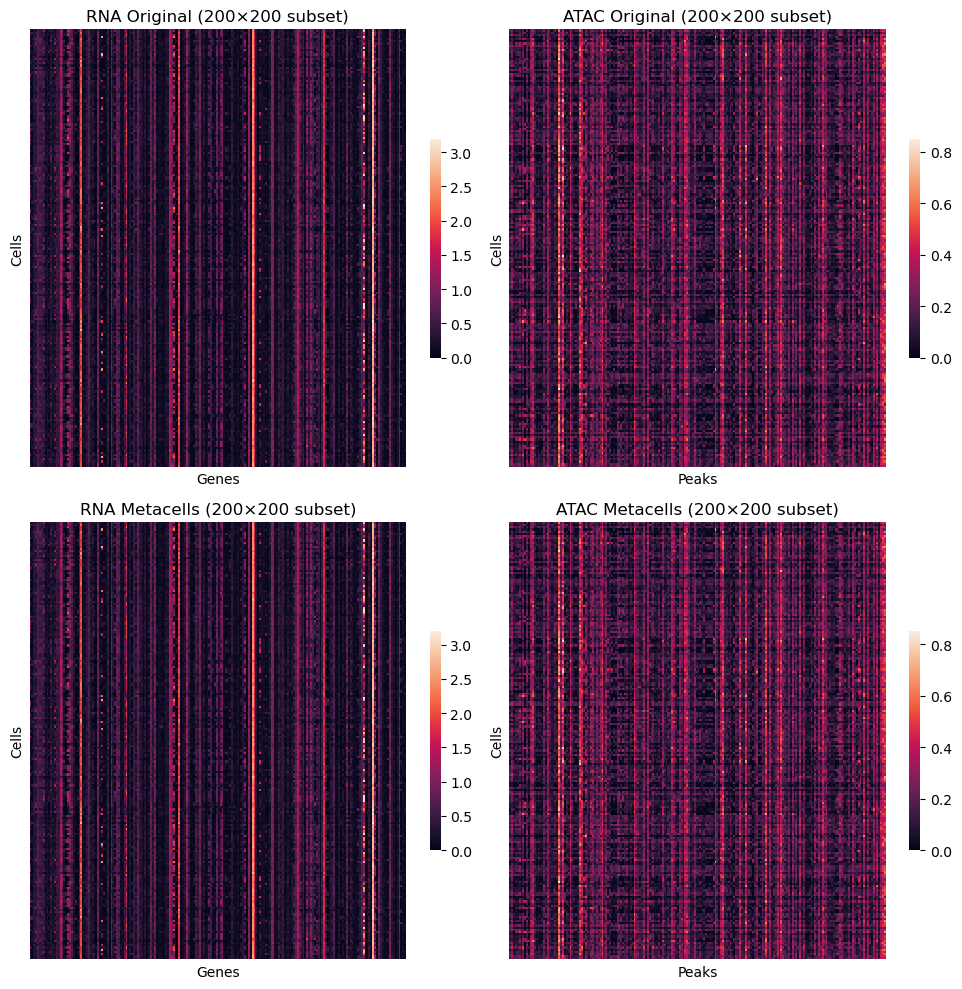

In [110]:

def to_dense_subset(X, n_cells=200, n_features=200):
    if sp.issparse(X):
        X = X[:n_cells, :n_features].toarray()
    else:
        X = np.asarray(X[:n_cells, :n_features])
    return X

# choose a subset
Xr_orig = to_dense_subset(X_rna, n_cells=200, n_features=200)
Xa_orig = to_dense_subset(X_rna, n_cells=200, n_features=200)
Xr = to_dense_subset(X_rna_soft, n_cells=200, n_features=200)
Xa = to_dense_subset(X_atac_soft, n_cells=200, n_features=200)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
sns.heatmap(Xr, ax=ax[0, 0], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[0, 0].set_title("RNA Original (200×200 subset)")
ax[0, 0].set_xlabel("Genes")
ax[0, 0].set_ylabel("Cells")

sns.heatmap(Xa, ax=ax[0, 1], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[0, 1].set_title("ATAC Original (200×200 subset)")
ax[0, 1].set_xlabel("Peaks")
ax[0, 1].set_ylabel("Cells")


sns.heatmap(Xr, ax=ax[1, 0], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[1, 0].set_title("RNA Metacells (200×200 subset)")
ax[1, 0].set_xlabel("Genes")
ax[1, 0].set_ylabel("Cells")

sns.heatmap(Xa, ax=ax[1, 1], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[1, 1].set_title("ATAC Metacells (200×200 subset)")
ax[1, 1].set_xlabel("Peaks")
ax[1, 1].set_ylabel("Cells")

plt.tight_layout()
plt.show()

Show how the cells cluster by their expression and accessibility profiles before and after diffusion.

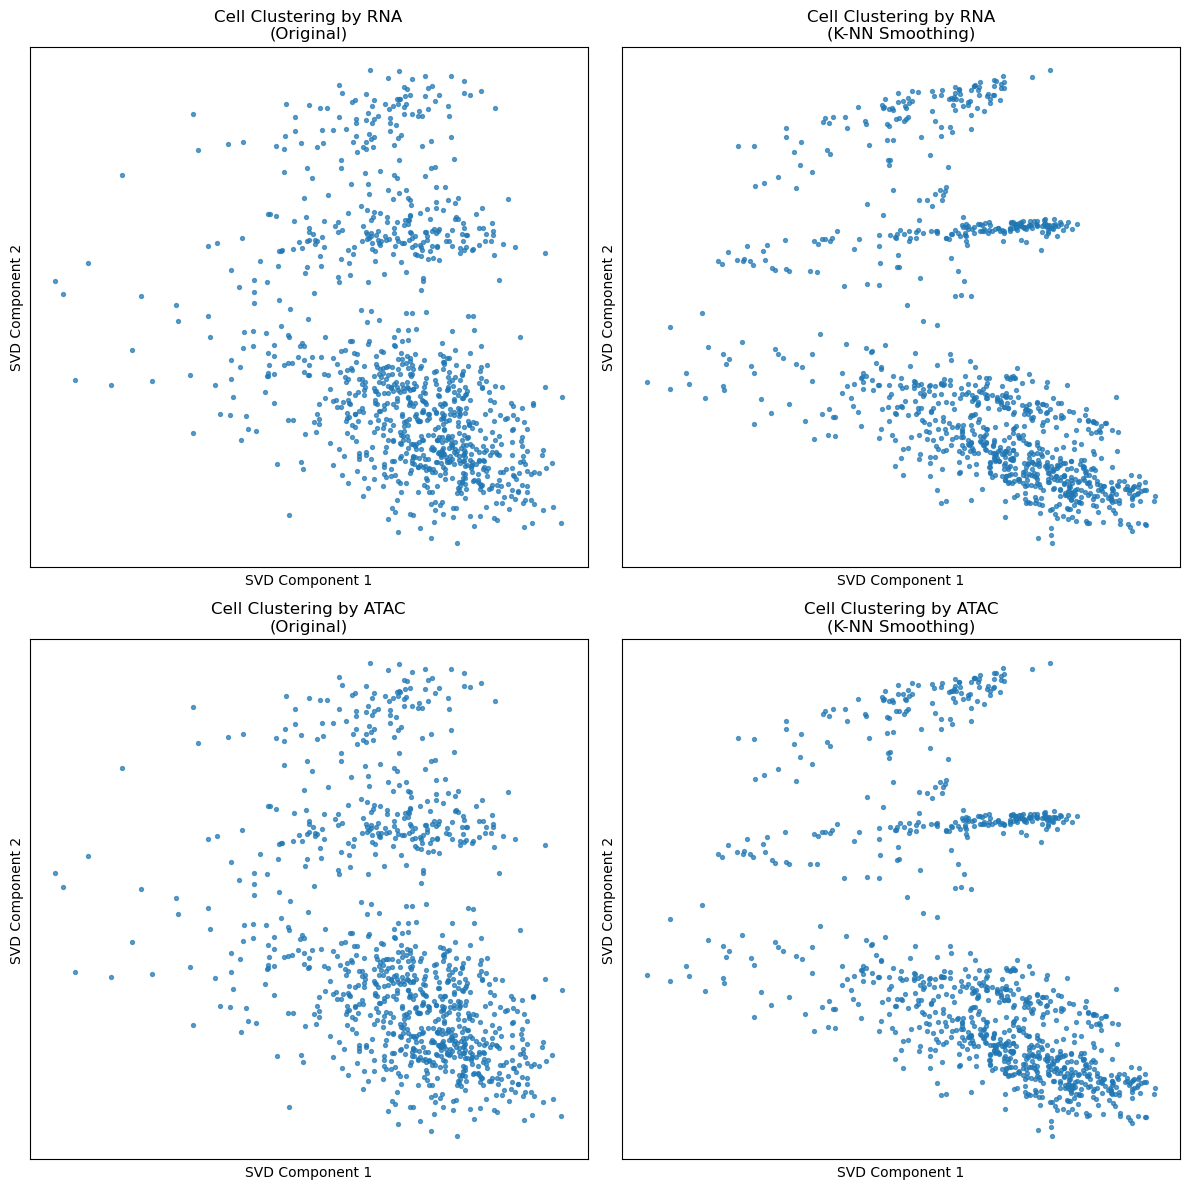

In [ ]:
from sklearn.decomposition import TruncatedSVD
def fit_svd_2d(X, n_cells=1000, n_features=1000):
    if sp.issparse(X):
        Xsub = X[:n_cells, :n_features]
    else:
        Xsub = np.asarray(X[:n_cells, :n_features])
    svd = TruncatedSVD(n_components=2, random_state=0)
    coords = svd.fit_transform(Xsub)
    return coords

rna_orig_2d = fit_svd_2d(X_rna)
rna_soft_2d = fit_svd_2d(X_rna_soft)

atac_orig_2d = fit_svd_2d(X_atac)
atac_soft_2d = fit_svd_2d(X_atac_soft)

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

ax[0,0].scatter(rna_orig_2d[:, 0], rna_orig_2d[:, 1], s=8, alpha=0.7)
ax[0,0].set_title("Cell Clustering by RNA\n(Original)")
ax[0,0].set_xlabel("SVD Component 1")
ax[0,0].set_ylabel("SVD Component 2")
ax[0,0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

ax[0,1].scatter(rna_soft_2d[:, 0], rna_soft_2d[:, 1], s=8, alpha=0.7)
ax[0,1].set_title("Cell Clustering by RNA\n(K-NN Smoothing)")
ax[0,1].set_xlabel("SVD Component 1")
ax[0,1].set_ylabel("SVD Component 2")
ax[0,1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

ax[1,0].scatter(rna_orig_2d[:, 0], rna_orig_2d[:, 1], s=8, alpha=0.7)
ax[1,0].set_title("Cell Clustering by ATAC\n(Original)")
ax[1,0].set_xlabel("SVD Component 1")
ax[1,0].set_ylabel("SVD Component 2")
ax[1,0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

ax[1,1].scatter(rna_soft_2d[:, 0], rna_soft_2d[:, 1], s=8, alpha=0.7)
ax[1,1].set_title("Cell Clustering by ATAC\n(K-NN Smoothing)")
ax[1,1].set_xlabel("SVD Component 1")
ax[1,1].set_ylabel("SVD Component 2")
ax[1,1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.show()

## Create and save the pseudobulk DataFrames

In [117]:
def _standardize_symbols_index(
    df: pd.DataFrame,
    *,
    strip_version_suffix: bool = True,
    uppercase: bool = True,
    deduplicate: str = "sum",
) -> pd.DataFrame:
    x = df.copy()
    idx = x.index.astype(str).str.strip()
    if strip_version_suffix:
        idx = idx.str.replace(r"\.\d+$", "", regex=True)
    if uppercase:
        idx = idx.str.upper()
    x.index = idx
    if deduplicate:
        if deduplicate == "sum":
            x = x.groupby(level=0).sum()
        elif deduplicate == "mean":
            x = x.groupby(level=0).mean()
        elif deduplicate == "first":
            x = x[~x.index.duplicated(keep="first")]
        elif deduplicate in {"max", "min", "median"}:
            x = getattr(x.groupby(level=0), deduplicate)()
        else:
            raise ValueError(f"Unknown deduplicate policy: {deduplicate}")
    return x

In [118]:
pseudo_bulk_rna_df = pd.DataFrame(
    X_rna_soft.T.toarray(),
    index=ad_rna.var_names,
    columns=ad_rna.obs_names,
).fillna(0)
pseudo_bulk_atac_df = pd.DataFrame(
    X_atac_soft.T.toarray(),
    index=ad_atac.var_names,
    columns=ad_atac.obs_names,
).fillna(0)

pseudo_bulk_rna_df = _standardize_symbols_index(pseudo_bulk_rna_df)

In [119]:
pseudobulk_rna_file = PROCESSED_DATA_DIR / "TG_pseudobulk.parquet"
pseudobulk_atac_file = PROCESSED_DATA_DIR / "RE_pseudobulk.parquet"

pseudo_bulk_rna_df.to_parquet(pseudobulk_rna_file, engine="pyarrow", compression="snappy")
pseudo_bulk_atac_df.to_parquet(pseudobulk_atac_file, engine="pyarrow", compression="snappy")
    